<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
ciudades=pd.read_csv("/content/base_mobilev2.csv")

In [2]:
num_valores = ciudades['Desigualdad_10km'].count()
print(f"Número de valores no nulos en 'Desigualdad_10km': {num_valores}")

Número de valores no nulos en 'Desigualdad_10km': 1095


In [3]:
top_ciudades = ciudades.nlargest(10, 'Desigualdad_10km')

# Obtener los valores de la columna 'City'
top_ciudades_list = top_ciudades['City'].tolist()

print(top_ciudades_list)

['MX: Norte/Sonora/Cajeme', 'PY: Alto Parana-Hernandarias', 'PY: Alto Parana-Yguazu', 'PY: Alto Parana-Minga Pora', 'PY: Alto Parana-San Alberto', 'MX: Centro/Queretaro/Colon', 'CL: Valparaiso-Quillota', 'VE: Carabobo-Puerto Cabello', 'BO: Oruro-Oruro', 'BR: Sul-Gravatai']


In [4]:
top_ciudades = ciudades.nsmallest(10, 'Desigualdad_10km')

# Obtener los valores de la columna 'City'
top_ciudades_list = top_ciudades['City'].tolist()

print(top_ciudades_list)

['BR: Norte-Para-Sao Felix do Xingu', 'GT: San Marcos-Concepcion Tutuapa', 'HO: Lempira-Talgua', 'PA: Ngobe Bugle-Besiko', 'PA: Chiriqui-Renacimiento', 'PA: Veraguas-Santa Fe', 'HO: Lempira-Lepaera', 'SV: Chalatenango-Chalatenango', 'PA: Veraguas-Sona', 'EC: Manabi-Pajan']


In [6]:
ciudades[ciudades['City'] == 'HO: Lempira-Talgua']

,Unnamed: 0.6,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,City,Latitude,Longitude,...,avg_lat_ms,tests,devices,Desigualdad_1km,Desigualdad_10km,Diferencia,P1ST,Desigualdad_5km,Desigualdad_15km,Desigualdad_promedio
713,713,713,713,713,713,713,728,HO: Lempira-Talgua,14.681111,-88.727778,...,50,1,1,0.391978,0.373848,NaN,3.3,0.399161,0.394659,37.384834


# Gráficos y Regresiones

In [7]:
import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit(cov_type='HC1')

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     61.62
Date:                Wed, 14 May 2025   Prob (F-statistic):           9.88e-15
Time:                        14:18:13   Log-Likelihood:                -454.57
No. Observations:                1095   AIC:                             913.1
Df Residuals:                    1093   BIC:                             923.1
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.1786      0.135  

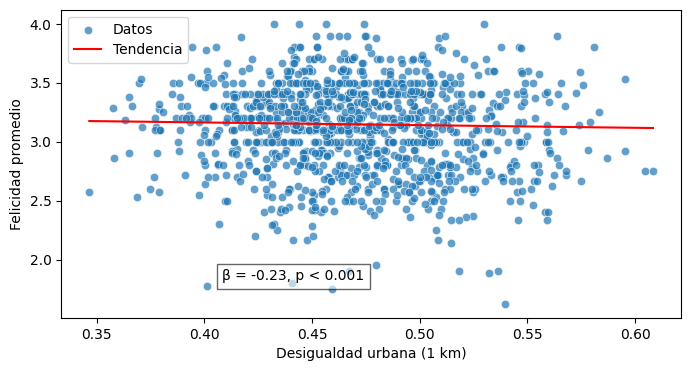

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Definir coeficientes de la regresión
intercept = 3.2529
slope = -0.2262
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_1km", y="P1ST", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_1km"].max()-0.2, ciudades["P1ST"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (1 km)")
plt.ylabel("Felicidad promedio")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico
plt.show()

In [9]:
# Definir variables
X = ciudades["Desigualdad_15km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit(cov_type='HC1')

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   P1ST   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     40.98
Date:                Wed, 14 May 2025   Prob (F-statistic):           2.28e-10
Time:                        14:18:26   Log-Likelihood:                -468.30
No. Observations:                1095   AIC:                             940.6
Df Residuals:                    1093   BIC:                             950.6
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.9352      0.128  

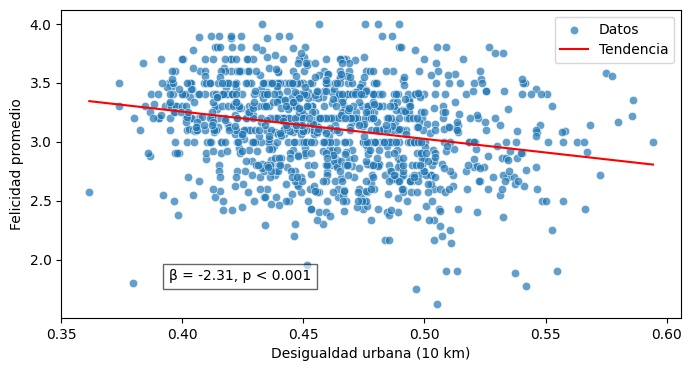

In [ ]:
# Definir coeficientes de la regresión
intercept = 4.1786
slope = -2.3106
p_value = "< 0.001"  # Significancia del coeficiente

# Calcular valores ajustados para la línea de tendencia
x_vals = np.linspace(ciudades["Desigualdad_10km"].min(), ciudades["Desigualdad_10km"].max(), 100)
y_vals = intercept + slope * x_vals  # Ecuación de la regresión

# Crear la figura
plt.figure(figsize=(8, 4))

# Graficar los datos (X = desigualdad, Y = felicidad)
sns.scatterplot(data=ciudades, x="Desigualdad_10km", y="P1ST", alpha=0.7, label="Datos")

# Graficar la línea de tendencia correctamente orientada
plt.plot(x_vals, y_vals, color="red", label=f"Tendencia")

# Agregar información sobre la significancia del coeficiente en el gráfico
plt.text(ciudades["Desigualdad_10km"].max()-0.2, ciudades["P1ST"].min()+0.2, f"β = {slope:.2f}, p {p_value}",
         fontsize=10, color="black", bbox=dict(facecolor="white", alpha=0.6))

# Etiquetas y título
plt.xlabel("Desigualdad urbana (10 km)")
plt.ylabel("Felicidad promedio")
#plt.title("Relación entre desigualdad urbana y felicidad")
plt.legend()

# Mostrar el gráfico

plt.show()

# Placebo Test

In [ ]:
ciudades["placebo_felicidad"] = np.random.randint(1,5, size=len(ciudades))
ciudades["placebo_desigualdad"] = np.random.uniform(ciudades["Desigualdad_1km"].min(), ciudades["Desigualdad_1km"].max(), size=len(ciudades))

In [ ]:
# Definir variables
X = ciudades["placebo_desigualdad"].replace([np.inf, -np.inf], np.nan)
y = ciudades["P1ST"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit(cov_type='HC1')

# Resumen de la regresión
print(modelo.summary())

# Submuestras

In [53]:
import numpy as np

latino=pd.read_stata('/content/Latinobarometro_2023_Esp_Stata_v1_0.dta')

conversion = {
    "No muy satisfecho": 2,
    "Para nada satisfecho": 1,
    "Bastante satisfecho": 3,
    "Muy satisfecho": 4
}

# Reemplazar valores en la columna P1ST
latino["felicidad"] = latino["P1ST"].map(conversion)

In [54]:
latino.P61ST=latino.P61ST.replace('01 Completamente inaceptable',1).replace('10 Completamente aceptable',10).replace('No sabe',np.nan).replace('No contesta',np.nan).astype(float)

<ipython-input-54-85a1ff755002>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  latino.P61ST=latino.P61ST.replace('01 Completamente inaceptable',1).replace('10 Completamente aceptable',10).replace('No sabe',np.nan).replace('No contesta',np.nan).astype(float)


In [55]:
latino['aceptacion_desigualdad'] = (11 - latino['P61ST']).astype(float)

In [56]:
columnas = ['S14M_A', 'S14M_B', 'S14M_C', 'S14M_D', 'S14M_E', 'S14M_F', 'S14M_G', 'S14M_H']

latino['redes'] = latino[columnas].apply(lambda row: 1 if 'Menciona' in row.values else 0, axis=1)

In [57]:
latino["S5"] = latino["S5"].replace({
    'No les alcanza, tienen grandes dificultades': 0,
    'No les alcanza, tienen dificultades': 1,
    'Les alcanza justo, sin grandes dificultades': 2,
    'Les alcanza bien, pueden ahorrar': 3,
    'No sabe': np.nan,
    'No contesta': np.nan
}).astype(float)

<ipython-input-57-d233daf810fc>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  latino["S5"] = latino["S5"].replace({
<ipython-input-57-d233daf810fc>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  latino["S5"] = latino["S5"].replace({


In [58]:
latino["ingreso_subjetivo"]=latino["S5"]

In [59]:
# Diccionario de mapeo para asignar valores numéricos según los años de estudio
years_map = {
    "12 anos": 12,
    "Universitario completo": 16,  # Suponiendo que la educación universitaria completa es equivalente a 16 años
    "Instituto superior/academias/Formacion tecnica completa": 14,
    "10 anos": 10,
    "11 anos": 11,
    "7 anos": 7,
    "Universitario incompleto": 14,  # Suposición de 14 años
    "Instituto superior/academias/Formacion tecnica incompleta": 13,
    "9 anos": 9,
    "6 anos": 6,
    "8 anos": 8,
    "Sin estudios": 0,  # Si no tiene estudios, se asigna 0 años
    "3 anos": 3,
    "5 anos": 5,
    "1 ano": 1,
    "4 anos": 4,
    "2 anos": 2
}

# Crear una nueva variable con los años de estudio
latino['años_estudio'] = latino['S11'].map(years_map)

In [60]:
mapa_conversion = {
    'Muy injusta': 4,
    'Injusta': 3,
    'Justa': 2,
    'Muy justa': 1,
    'No sabe': np.nan,
    'No contesta': np.nan
}

# Convertir la columna P17ST a valores float según el diccionario
latino['desigualdad_subjetiva'] = latino['P17ST'].map(mapa_conversion)

In [19]:
latino=latino.groupby("ciudad", as_index=False, observed=True).agg({
    "felicidad": "mean",
    "aceptacion_desigualdad": "mean",
    "redes": "mean",
    "ingreso_subjetivo": "mean",
    "desigualdad_subjetiva": "mean",
    "años_estudio": "mean",
    "tamciud": "first" , # Mantiene el primer valor de tamciud por ciudad
    "idenpa": "first"
})

In [20]:
ciudades=ciudades.merge(latino, left_on="City", right_on="ciudad", how="left")

In [21]:
# Corre la variable de desigualdad creada por imagenes satelitales contra la variable sibjetiva de desigualdad

import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["desigualdad_subjetiva"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit(cov_type='HC1')

# Resumen de la regresión
print(modelo.summary())

                              OLS Regression Results                             
Dep. Variable:     desigualdad_subjetiva   R-squared:                       0.044
Model:                               OLS   Adj. R-squared:                  0.043
Method:                    Least Squares   F-statistic:                     52.52
Date:                   Wed, 14 May 2025   Prob (F-statistic):           8.05e-13
Time:                           14:19:21   Log-Likelihood:                -422.72
No. Observations:                   1095   AIC:                             849.4
Df Residuals:                       1093   BIC:                             859.4
Df Model:                              1                                         
Covariance Type:                     HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const     

In [22]:
ciudades["capital"] = np.where(ciudades["tamciud"].isin(["(Capital)", "100.001 y más"]), 1, 0)

In [30]:
# Corre el modelo con varios regresores

# Definir variables
X = ciudades[["Desigualdad_10km", "redes", "ingreso_subjetivo", "capital", "años_estudio", "aceptacion_desigualdad"]].replace([np.inf, -np.inf], np.nan)
y = ciudades["felicidad"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit(cov_type='HC1')

# Resumen de la regresión
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:              felicidad   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     27.03
Date:                Wed, 14 May 2025   Prob (F-statistic):           3.87e-30
Time:                        14:22:00   Log-Likelihood:                -420.00
No. Observations:                1095   AIC:                             854.0
Df Residuals:                    1088   BIC:                             889.0
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4

In [32]:
!pip install stargazer

In [36]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from stargazer.stargazer import Stargazer

# Definir variables
X_full = ciudades[["Desigualdad_1km", "Desigualdad_5km","Desigualdad_10km", "Desigualdad_15km","redes", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]].replace([np.inf, -np.inf], np.nan)
y = ciudades["felicidad"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X_full.notna().all(axis=1) & y.notna()
X_full, y = X_full[mask], y[mask]

# Agregar constante para la ordenada al origen
X_full = sm.add_constant(X_full)

# Especificaciones del modelo
X_spec1 = X_full[["const", "Desigualdad_1km", "redes", "ingreso_subjetivo", "capital", "años_estudio"]]  # Modelo 1
X_spec2 = X_full[["const", "Desigualdad_5km", "redes", "ingreso_subjetivo", "capital", "años_estudio"]]  # Modelo 2
X_spec3 = X_full[["const","Desigualdad_15km", "redes", "ingreso_subjetivo", "capital", "años_estudio"]]
X_spec4 = X_full[["const", "Desigualdad_10km"]]
X_spec5 = X_full[["const","redes", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]]
X_spec6 = X_full[["const","Desigualdad_10km","redes", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]]

# Ajustar modelos
modelo1 = sm.OLS(y, X_spec1).fit(cov_type='HC1')
modelo2 = sm.OLS(y, X_spec2).fit(cov_type='HC1')
modelo3 = sm.OLS(y, X_spec3).fit(cov_type='HC1')
modelo4 = sm.OLS(y, X_spec4).fit(cov_type='HC1')
modelo5 = sm.OLS(y, X_spec5).fit(cov_type='HC1')
modelo6 = sm.OLS(y, X_spec6).fit(cov_type='HC1')

# Crear tabla en LaTeX
stargazer = Stargazer([modelo1, modelo2, modelo3, modelo4, modelo5, modelo6])
stargazer.title("Regresión de felicidad sobre desigualdad y otras variables")
stargazer.significance_levels([0.1, 0.05, 0.01])  # Definir niveles de significancia
stargazer.covariate_order(["Desigualdad_1km", "Desigualdad_5km","Desigualdad_10km","Desigualdad_15km", "redes", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva",  "aceptacion_desigualdad", "const"])

# Remover estadísticos no deseados
stargazer.show_f_statistic = False
stargazer.show_adj_r2 = False
stargazer.show_residual_std_err = False
stargazer.show_n=False
stargazer.show_notes=False


# Función para limpiar nombres de variables para LaTeX
def clean_variable_names(name):
    return name.replace("_", "\_").replace("ñ", "ni")  # Escapar _ y reemplazar ñ

# Aplicar la función a los nombres de las variables en la tabla
stargazer.rename_covariates({col: clean_variable_names(col) for col in X_full.columns})

latex_output = stargazer.render_latex()
custom_note = r"\floatfoot{Nota: Se muestra la salida del modelo para diversas especificaciones. En todos los casos los valores estimados para el efecto del indicador de desigualdad objetiva resultan significativos. N=1095, *** p<0.01, ** p<0.05, * p<0.1}"
latex_output = latex_output.replace(r"\end{table}", custom_note + r"\end{table}")

# Guardar en un archivo .tex
with open("tabla_modelos.tex", "w") as f:
    f.write(latex_output)


In [51]:
import pandas as pd

# Seleccionar variables
vars_interes = ["Desigualdad_1km", "Desigualdad_5km","Desigualdad_10km", "Desigualdad_15km", "redes", "ingreso_subjetivo", "capital",
                "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]

# Calcular estadísticas descriptivas
tabla_descriptiva = ciudades[vars_interes].describe().T

tabla_descriptiva = tabla_descriptiva.drop(columns=["count"])

# Renombrar columnas para mayor claridad
tabla_descriptiva = tabla_descriptiva.rename(columns={
    "mean": "Media",
    "std": "Desv.Est",
    "min": "Mín.",
    "25%": "P25",
    "50%": "Med.",
    "75%": "P75",
    "max": "Máx."
})

tabla_descriptiva.index = (tabla_descriptiva.index
    .str.replace("ñ", "ni")
    .str.replace("_", " ")  # Opcional, para mejorar la legibilidad
)

# Convertir a LaTeX
tabla_latex = tabla_descriptiva.to_latex(float_format="%.2f")



# Agregar un título y centrar la tabla en LaTeX
tabla_latex = r"""
\begin{table}[htbp]
    \centering
    \caption{Estadísticas descriptivas}
    \label{tab:desc}
    """ + tabla_descriptiva.to_latex(float_format="%.2f", escape=False) + r"""

\floatfoot{Nota: Se presentan las principales estadísticas descriptivas de las variables utilizadas. N=1095}
\end{table}
"""

# Guardar en un archivo .tex
with open("tabla_descriptiva.tex", "w") as f:
    f.write(tabla_latex)

# Regresión Cuantílica

In [ ]:
import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades[["Desigualdad_10km", "redes", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]].replace([np.inf, -np.inf], np.nan)
y = ciudades["felicidad"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

# Agregar constante
X = sm.add_constant(X)

# Modelo por cuantiles: ejemplo para el cuantil 0.5 (mediana)
modelo_qr = sm.QuantReg(y, X).fit(q=0.5, cov_type='robust')

# Resumen del modelo
print(modelo_qr.summary())


                         QuantReg Regression Results                          
Dep. Variable:              felicidad   Pseudo R-squared:              0.07657
Model:                       QuantReg   Bandwidth:                      0.1687
Method:                 Least Squares   Sparsity:                       0.8767
Date:                Fri, 25 Apr 2025   No. Observations:                 1095
Time:                        17:42:04   Df Residuals:                     1087
                                        Df Model:                            7
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      4.0336      0.198     20.368      0.000       3.645       4.422
Desigualdad_10km          -1.4794      0.360     -4.109      0.000      -2.186      -0.773
redes                      0.3055      0.120      2.539      0.011       0.069     

/usr/local/lib/python3.11/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


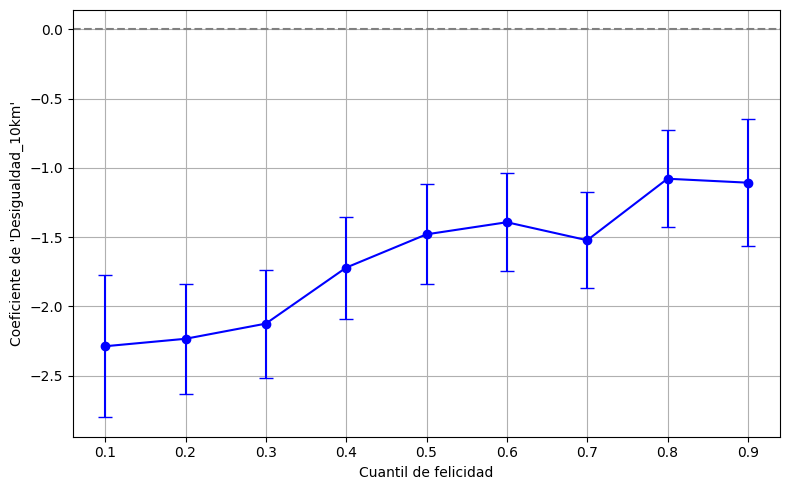

In [38]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definir cuantiles que te interesan
quantiles = [0.1, 0.2,0.3,0.4, 0.5, 0.6,0.7,0.8, 0.9]

# Crear listas para guardar coeficientes y errores estándar
coefs = []
ses = []

# Asegurate de tener los datos filtrados como antes
df = ciudades[["felicidad", "Desigualdad_10km", "redes", "ingreso_subjetivo", "capital", "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]].replace([np.inf, -np.inf], np.nan).dropna()

# Iterar sobre los cuantiles
for q in quantiles:
    mod = smf.quantreg("felicidad ~ Desigualdad_10km + redes + ingreso_subjetivo + capital + años_estudio + desigualdad_subjetiva + aceptacion_desigualdad", df)
    res = mod.fit(q=q, cov_type='HC1')
    coefs.append(res.params["Desigualdad_10km"])
    ses.append(res.bse["Desigualdad_10km"])

# Convertir a arrays para graficar
coefs = np.array(coefs)
ses = np.array(ses)

# Graficar
plt.figure(figsize=(8, 5))
plt.errorbar(quantiles, coefs, yerr=ses, fmt='o-', color='blue', capsize=5)
plt.axhline(0, color='gray', linestyle='--')
#plt.title("Impacto de la desigualdad visual sobre la felicidad por cuantil")
plt.xlabel("Cuantil de felicidad")
plt.ylabel("Coeficiente de 'Desigualdad_10km'")
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
coefs

array([-2.28727468, -2.23344939, -2.12396909, -1.71965299, -1.47936269,
       -1.39209406, -1.5220631 , -1.0780327 , -1.10654125])

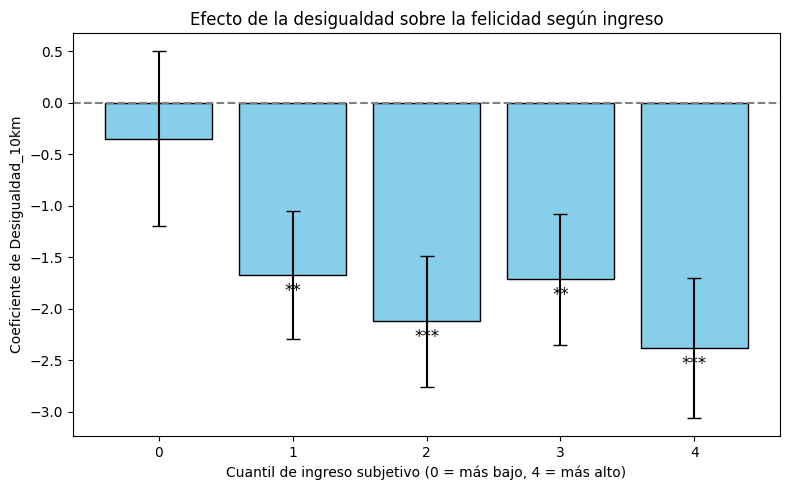

In [47]:
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Filtrar datos y eliminar valores extremos o nulos
df = ciudades[["felicidad", "Desigualdad_10km", "redes", "ingreso_subjetivo", "capital",
               "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]].replace([np.inf, -np.inf], np.nan).dropna()

# Crear cuantiles de ingreso subjetivo
df["q_ingreso"] = pd.qcut(df["ingreso_subjetivo"], q=5, labels=False)

# Listas para almacenar resultados
coeficientes = []
ses = []
pvalores = []
cuantiles = sorted(df["q_ingreso"].unique())

# Estimar regresiones por cuantil
for q in cuantiles:
    subdf = df[df["q_ingreso"] == q]
    mod = smf.ols("felicidad ~ Desigualdad_10km + redes + capital + años_estudio + desigualdad_subjetiva + aceptacion_desigualdad", subdf)
    res = mod.fit(cov_type="HC1")
    coeficientes.append(res.params["Desigualdad_10km"])
    ses.append(res.bse["Desigualdad_10km"])
    pvalores.append(res.pvalues["Desigualdad_10km"])

# Graficar
plt.figure(figsize=(8, 5))
bars = plt.bar(cuantiles, coeficientes, yerr=ses, capsize=5, color='skyblue', edgecolor='black')

# Agregar asteriscos de significancia
for i, p in enumerate(pvalores):
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = ''
    plt.text(cuantiles[i], coeficientes[i] + np.sign(coeficientes[i]) * 0.2, sig, ha='center', fontsize=12)

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Cuantil de ingreso subjetivo (0 = más bajo, 4 = más alto)")
plt.ylabel("Coeficiente de Desigualdad_10km")
plt.title("Efecto de la desigualdad sobre la felicidad según ingreso")
plt.tight_layout()
plt.show()


# Colapsar a nivel individual

In [252]:
ciudades=pd.read_csv("/content/base_mobilev2.csv")

In [253]:
import numpy as np

latino=pd.read_stata('/content/Latinobarometro_2023_Esp_Stata_v1_0.dta')

conversion = {
    "No muy satisfecho": 2,
    "Para nada satisfecho": 1,
    "Bastante satisfecho": 3,
    "Muy satisfecho": 4
}

# Reemplazar valores en la columna P1ST
latino["felicidad"] = latino["P1ST"].map(conversion)

In [254]:
latino.P61ST=latino.P61ST.replace('01 Completamente inaceptable',1).replace('10 Completamente aceptable',10).replace('No sabe',np.nan).replace('No contesta',np.nan).astype(float)

<ipython-input-254-85a1ff755002>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  latino.P61ST=latino.P61ST.replace('01 Completamente inaceptable',1).replace('10 Completamente aceptable',10).replace('No sabe',np.nan).replace('No contesta',np.nan).astype(float)


In [255]:
latino['aceptacion_desigualdad'] = (11 - latino['P61ST']).astype(float)

In [256]:
columnas = ['S14M_A', 'S14M_B', 'S14M_C', 'S14M_D', 'S14M_E', 'S14M_F', 'S14M_G', 'S14M_H']

latino['redes'] = latino[columnas].apply(lambda row: 1 if 'Menciona' in row.values else 0, axis=1)

In [257]:
latino["S5"] = latino["S5"].replace({
    'No les alcanza, tienen grandes dificultades': 0,
    'No les alcanza, tienen dificultades': 1,
    'Les alcanza justo, sin grandes dificultades': 2,
    'Les alcanza bien, pueden ahorrar': 3,
    'No sabe': np.nan,
    'No contesta': np.nan
}).astype(float)

<ipython-input-257-d233daf810fc>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  latino["S5"] = latino["S5"].replace({
<ipython-input-257-d233daf810fc>:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  latino["S5"] = latino["S5"].replace({


In [258]:
latino["ingreso_subjetivo"]=latino["S5"]

In [259]:
latino["ingreso_subjetivo"].unique()

array([ 0.,  1.,  3.,  2., nan])

In [260]:
# Diccionario de mapeo para asignar valores numéricos según los años de estudio
years_map = {
    "12 anos": 12,
    "Universitario completo": 16,  # Suponiendo que la educación universitaria completa es equivalente a 16 años
    "Instituto superior/academias/Formacion tecnica completa": 14,
    "10 anos": 10,
    "11 anos": 11,
    "7 anos": 7,
    "Universitario incompleto": 14,  # Suposición de 14 años
    "Instituto superior/academias/Formacion tecnica incompleta": 13,
    "9 anos": 9,
    "6 anos": 6,
    "8 anos": 8,
    "Sin estudios": 0,  # Si no tiene estudios, se asigna 0 años
    "3 anos": 3,
    "5 anos": 5,
    "1 ano": 1,
    "4 anos": 4,
    "2 anos": 2
}

# Crear una nueva variable con los años de estudio
latino['años_estudio'] = latino['S11'].map(years_map)

In [261]:
mapa_conversion = {
    'Muy injusta': 4,
    'Injusta': 3,
    'Justa': 2,
    'Muy justa': 1,
    'No sabe': np.nan,
    'No contesta': np.nan
}

# Convertir la columna P17ST a valores float según el diccionario
latino['desigualdad_subjetiva'] = latino['P17ST'].map(mapa_conversion)

In [262]:
latino.columns

Index(['numinves', 'idenpa', 'numentre', 'reg', 'ciudad', 'tamciud', 'comdist',
       'edad', 'sexo', 'codigo',
       ...
       'reedad', 'perpart', 'fampart', 'wt', 'felicidad',
       'aceptacion_desigualdad', 'redes', 'ingreso_subjetivo', 'años_estudio',
       'desigualdad_subjetiva'],
      dtype='object', length=280)

In [263]:
ciudades['ciudad']=ciudades['City']

In [264]:
latino["capital"] = np.where(latino["tamciud"].isin(["(Capital)", "100.001 y más"]), 1, 0)

In [265]:
latino["grupo_ingreso"] = (
    latino["ingreso_subjetivo"]
    .fillna(-1)   # o algún valor válido según tu escala
    .astype(int)
)


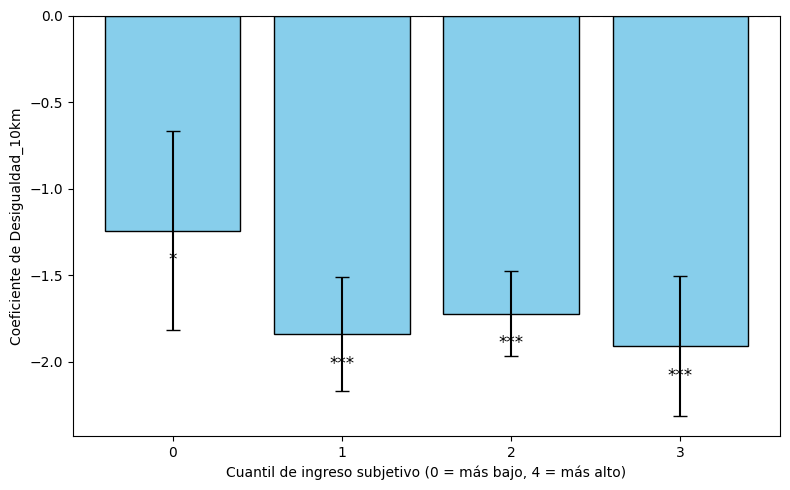

In [266]:
# Asegurate de que ambas columnas 'ciudad' estén en el mismo formato
latino = latino.merge(ciudades[["ciudad", "Desigualdad_10km"]], on="ciudad", how="left")
latino[["ciudad", "Desigualdad_10km"]].drop_duplicates().head()
df = latino[["felicidad", "Desigualdad_10km", "redes", "grupo_ingreso", "capital",
             "años_estudio", "desigualdad_subjetiva", "aceptacion_desigualdad"]].replace([np.inf, -np.inf], np.nan).dropna()
# Crear cuantiles de ingreso subjetivo
df["q_ingreso"] = pd.qcut(df["grupo_ingreso"], q=10, labels=False, duplicates='drop')


# Listas para almacenar resultados
coeficientes = []
ses = []
pvalores = []
cuantiles = sorted(df["q_ingreso"].unique())

# Estimar regresiones por cuantil
for q in cuantiles:
    subdf = df[df["q_ingreso"] == q]
    mod = smf.ols("felicidad ~ Desigualdad_10km + redes + capital + años_estudio + desigualdad_subjetiva + aceptacion_desigualdad", subdf)
    res = mod.fit(cov_type="HC1")
    coeficientes.append(res.params["Desigualdad_10km"])
    ses.append(res.bse["Desigualdad_10km"])
    pvalores.append(res.pvalues["Desigualdad_10km"])

# Graficar
plt.figure(figsize=(8, 5))
bars = plt.bar(cuantiles, coeficientes, yerr=ses, capsize=5, color='skyblue', edgecolor='black')

# Agregar asteriscos de significancia
for i, p in enumerate(pvalores):
    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = ''
    plt.text(cuantiles[i], coeficientes[i] + np.sign(coeficientes[i]) * 0.2, sig, ha='center', fontsize=12)

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Cuantil de ingreso subjetivo (0 = más bajo, 4 = más alto)")
plt.ylabel("Coeficiente de Desigualdad_10km")
plt.xticks(cuantiles)
#plt.title("Efecto de la desigualdad sobre la felicidad según ingreso")
plt.tight_layout()
plt.show()

In [267]:
mod = smf.ols("felicidad ~ Desigualdad_10km + redes + capital + años_estudio + desigualdad_subjetiva + aceptacion_desigualdad", df)
res = mod.fit(cov_type="HC1")
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              felicidad   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     80.86
Date:                Wed, 14 May 2025   Prob (F-statistic):          3.45e-100
Time:                        18:44:16   Log-Likelihood:                -21518.
No. Observations:               17451   AIC:                         4.305e+04
Df Residuals:                   17444   BIC:                         4.310e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  4.0041      0.083     48.129      0.000       3.841       4.167
Desigualdad_10km          -1.6699      0.173     -9.652      0.000      -2.009      -1.331
redes                      0.1517      0.023      6.493      0.000       0.106       0.198
capital                   -0.0565      0.017     -3.249      0.001      -0.091      -0.022
años_estudio               0.0156      0.002      9.255      0.000       0.012       0.019
desigualdad_subjetiva     -0.0932      0.008    -11.123      0.000      -0.110      -0.077
aceptacion_desigualdad    -0.0142      0.002     -6.137      0.000      -0.019      -0.010
==============================================================================
Omnibus:                     1079.097   Durbin-Watson:                   1.812
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1199.630
Skew:                          -0.618   Prob(JB):                    3.19e-261
Kurtosis:                       2.651   Cond. No.                         399.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""